# 05 — Efeito da Fração Observada na Capacidade Preditiva

**Pergunta:** Quantos produtos observados em uma cesta são necessários para prever corretamente
uma fração significativa dos itens restantes?

O experimento varia a fração de itens observados (`n_obs`) em {25%, 50%, 75%} e avalia
quão bem cada método recupera os itens ocultos. Esta análise investiga:

1. Como recall e basket coverage mudam com `n_obs`
2. Por que o recall condicional é quase constante entre frações (decomposição de hits/|H|)
3. Qual fração observada é necessária para atingir uma cobertura mínima da cesta completa
4. Distribuição da cobertura por cesta (não apenas médias)

## 0. Setup

In [9]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (10, 5)})

RESULTS_PATH = '../outputs/results/experiment_results_merged.parquet'
TEST_DATA    = '../data/processed/test.parquet'

METHOD_LABELS  = {'popularity': 'Popularity', 'local_agg': 'LocalAgg', 'ppr': 'PPR'}
METHOD_ORDER   = ['popularity', 'local_agg', 'ppr']
METHOD_COLORS  = {'popularity': 'tab:gray', 'local_agg': 'tab:orange', 'ppr': 'tab:blue'}
N_OBS_FRACTIONS = [0.25, 0.5, 0.75]
FRAC_LABELS     = {0.25: '25%', 0.5: '50%', 0.75: '75%'}
K_VALUES        = [5, 10, 20]

## 1. Carregamento e Preparação

In [10]:
results = pd.read_parquet(RESULTS_PATH)
test_df = pd.read_parquet(TEST_DATA, columns=['basket_id', 'product_idx'])

# Cobertura do grafo (fator de correção do recall)
from src.graph_builder import load_graph
G = load_graph('../outputs/graphs')
graph_products = set(G.nodes())
all_test_products = set(test_df['product_idx'].unique())
GRAPH_COV = len(all_test_products & graph_products) / len(all_test_products)
print(f'Cobertura do grafo: {GRAPH_COV:.3f} ({100*GRAPH_COV:.1f}% dos produtos do teste estão no grafo)')
print(f'→ Recall verdadeiro ≈ recall condicional × {GRAPH_COV:.3f}\n')

# Média das repetições por cesta
per_basket_all = (
    results
    .groupby(['basket_id', 'n_obs', 'method', 'k'])[['precision', 'recall']]
    .mean()
    .reset_index()
)
denom = per_basket_all['precision'] + per_basket_all['recall']
per_basket_all['f1'] = np.where(
    denom == 0, 0.0,
    2 * per_basket_all['precision'] * per_basket_all['recall'] / denom.replace(0, np.nan),
)

# Tamanho de cada cesta (re-indexado para corresponder ao basket_id sequencial do experimento)
basket_sizes = (
    test_df.groupby('basket_id')['product_idx']
    .count()
    .reset_index(drop=True)
    .rename('basket_size')
    .rename_axis('basket_id')
    .reset_index()
)
print(f'Cestas únicas: {len(basket_sizes):,}')
print(f'Tamanho mediano: {basket_sizes["basket_size"].median():.0f}')
print(f'Shape per_basket_all: {per_basket_all.shape}')

Cobertura do grafo: 0.708 (70.8% dos produtos do teste estão no grafo)
→ Recall verdadeiro ≈ recall condicional × 0.708

Cestas únicas: 59,077
Tamanho mediano: 5
Shape per_basket_all: (901368, 7)


## 2. Recall Condicional vs Fração Observada

O recall condicional é calculado **somente sobre produtos presentes no grafo**.
Use o fator de correção (×0,708) para obter o recall verdadeiro sobre a cesta completa.

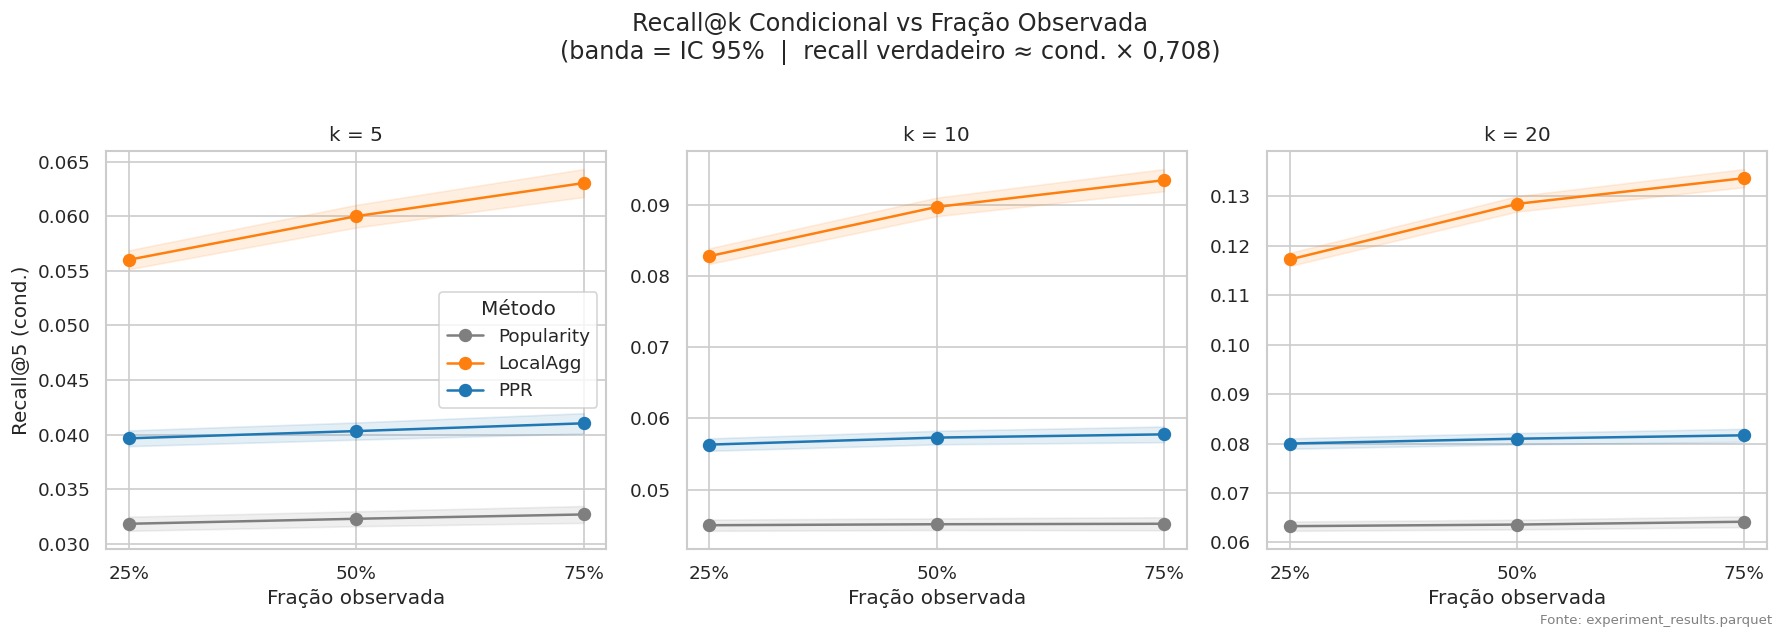

Média do Recall@k por n_obs × método (k=10):
method  Popularity  LocalAgg     PPR
n_obs                               
25%         0.0450    0.0828  0.0563
50%         0.0451    0.0897  0.0573
75%         0.0452    0.0934  0.0578


In [11]:
agg_recall = (
    per_basket_all
    .groupby(['n_obs', 'method', 'k'])['recall']
    .agg(['mean', 'sem'])  # standard error of the mean
    .reset_index()
)

fig, axes = plt.subplots(1, len(K_VALUES), figsize=(5*len(K_VALUES), 5), sharey=False)
for ax, k_val in zip(axes, K_VALUES):
    sub = agg_recall[agg_recall['k'] == k_val]
    for method in METHOD_ORDER:
        grp = sub[sub['method'] == method].sort_values('n_obs')
        ax.plot(grp['n_obs'], grp['mean'], marker='o', markersize=7,
                label=METHOD_LABELS[method], color=METHOD_COLORS[method])
        ax.fill_between(
            grp['n_obs'],
            (grp['mean'] - 1.96 * grp['sem']).clip(lower=0),
            grp['mean'] + 1.96 * grp['sem'],
            alpha=0.12, color=METHOD_COLORS[method],
        )
    ax.set_xticks(N_OBS_FRACTIONS)
    ax.set_xticklabels([FRAC_LABELS[f] for f in N_OBS_FRACTIONS])
    ax.set_xlabel('Fração observada')
    ax.set_ylabel(f'Recall@{k_val} (cond.)' if ax == axes[0] else '')
    ax.set_title(f'k = {k_val}')
    if ax == axes[0]:
        ax.legend(title='Método')
fig.suptitle('Recall@k Condicional vs Fração Observada\n(banda = IC 95%  |  recall verdadeiro ≈ cond. × 0,708)', y=1.03)
fig.text(0.99, 0.01, 'Fonte: experiment_results.parquet', ha='right', fontsize=8, color='gray')
plt.tight_layout()
plt.show()

print('Média do Recall@k por n_obs × método (k=10):')
print(agg_recall[agg_recall['k']==10]
      .pivot_table(index='n_obs', columns='method', values='mean')
      .rename(columns=METHOD_LABELS)[['Popularity','LocalAgg','PPR']]
      .rename(index=FRAC_LABELS).round(4))

## 3. Decomposição: Hits Absolutos vs Tamanho do Conjunto Oculto

**Por que o recall condicional é quase constante entre 25% e 75%?**

Recall@k = hits / |H|, onde |H| = itens ocultos = basket_size × (1 − n_obs).
Com n_obs crescente, tanto hits quanto |H| diminuem na mesma proporção.
Por isso o recall condicional não muda — é um artefato da métrica, não do modelo.

Decomposição do Recall@10:


implied_recall                   mean_hidden                     \
method_label       LocalAgg    PPR Popularity    LocalAgg     PPR Popularity   
n_obs_label                                                                    
25%                   0.068  0.048       0.04      11.873  11.873     11.873   
50%                   0.072  0.049       0.04       7.915   7.915      7.915   
75%                   0.075  0.050       0.04       3.958   3.958      3.958   

             mean_hits                    
method_label  LocalAgg    PPR Popularity  
n_obs_label                               
25%              0.809  0.572      0.474  
50%              0.571  0.387      0.318  
75%              0.296  0.196      0.160

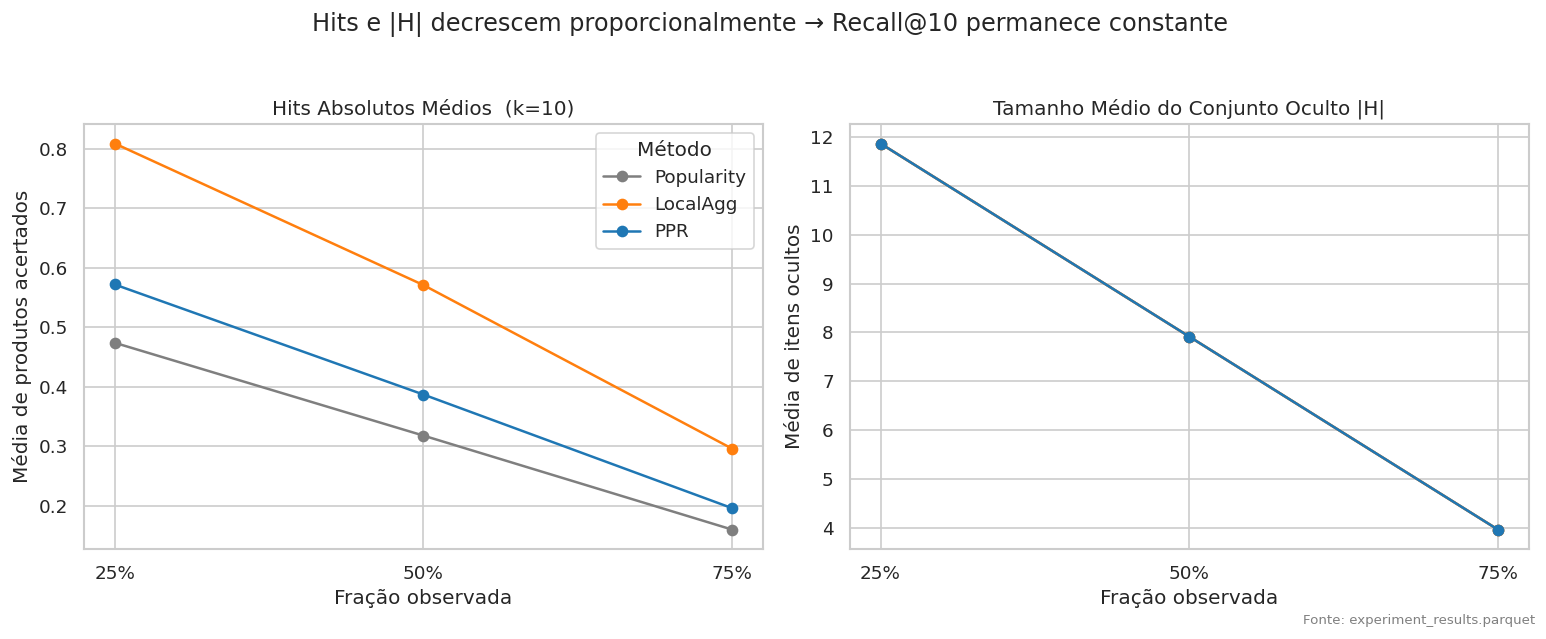

In [12]:
k_ref = 10
merged = (
    per_basket_all[per_basket_all['k'] == k_ref]
    .merge(basket_sizes, on='basket_id')
)
merged['n_hidden']   = (merged['basket_size'] * (1 - merged['n_obs'])).clip(lower=1)
merged['abs_hits']   = merged['recall'] * merged['n_hidden']
# basket_coverage: denominador fixo = basket_size completo
merged['basket_cov'] = merged['abs_hits'] / merged['basket_size']

decomp = (
    merged.groupby(['n_obs', 'method'])
    .agg(mean_hits=('abs_hits', 'mean'), mean_hidden=('n_hidden', 'mean'))
    .round(3).reset_index()
)
decomp['implied_recall'] = (decomp['mean_hits'] / decomp['mean_hidden']).round(4)
decomp['n_obs_label']    = decomp['n_obs'].map(FRAC_LABELS)
decomp['method_label']   = decomp['method'].map(METHOD_LABELS)

print(f'Decomposição do Recall@{k_ref}:')
display(
    decomp.pivot_table(index='n_obs_label', columns='method_label',
                       values=['mean_hidden', 'mean_hits', 'implied_recall'])
    .reindex([FRAC_LABELS[f] for f in N_OBS_FRACTIONS]).round(3)
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for method in METHOD_ORDER:
    sub = decomp[decomp['method'] == method]
    axes[0].plot(sub['n_obs_label'], sub['mean_hits'],   marker='o', label=METHOD_LABELS[method], color=METHOD_COLORS[method])
    axes[1].plot(sub['n_obs_label'], sub['mean_hidden'], marker='o', label=METHOD_LABELS[method], color=METHOD_COLORS[method])
axes[0].set_title(f'Hits Absolutos Médios  (k={k_ref})')
axes[0].set_ylabel('Média de produtos acertados')
axes[0].legend(title='Método')
axes[1].set_title('Tamanho Médio do Conjunto Oculto |H|')
axes[1].set_ylabel('Média de itens ocultos')
for ax in axes:
    ax.set_xlabel('Fração observada')
fig.suptitle(
    f'Hits e |H| decrescem proporcionalmente → Recall@{k_ref} permanece constante',
    y=1.03,
)
fig.text(0.99, 0.01, 'Fonte: experiment_results.parquet', ha='right', fontsize=8, color='gray')
plt.tight_layout()
plt.show()

## 4. Basket Coverage: Fração da Cesta Recuperada (denominador fixo)

`basket_coverage@k = hits / basket_size`

Diferente do recall condicional, esta métrica usa denominador **fixo** (tamanho total da cesta)
e responde diretamente: *'que fração da cesta o modelo consegue recuperar?'*

Se os métodos explorassem melhor o contexto adicional com n_obs maior, esperaríamos
um aumento de basket_coverage. O padrão que observamos revela o comportamento real.

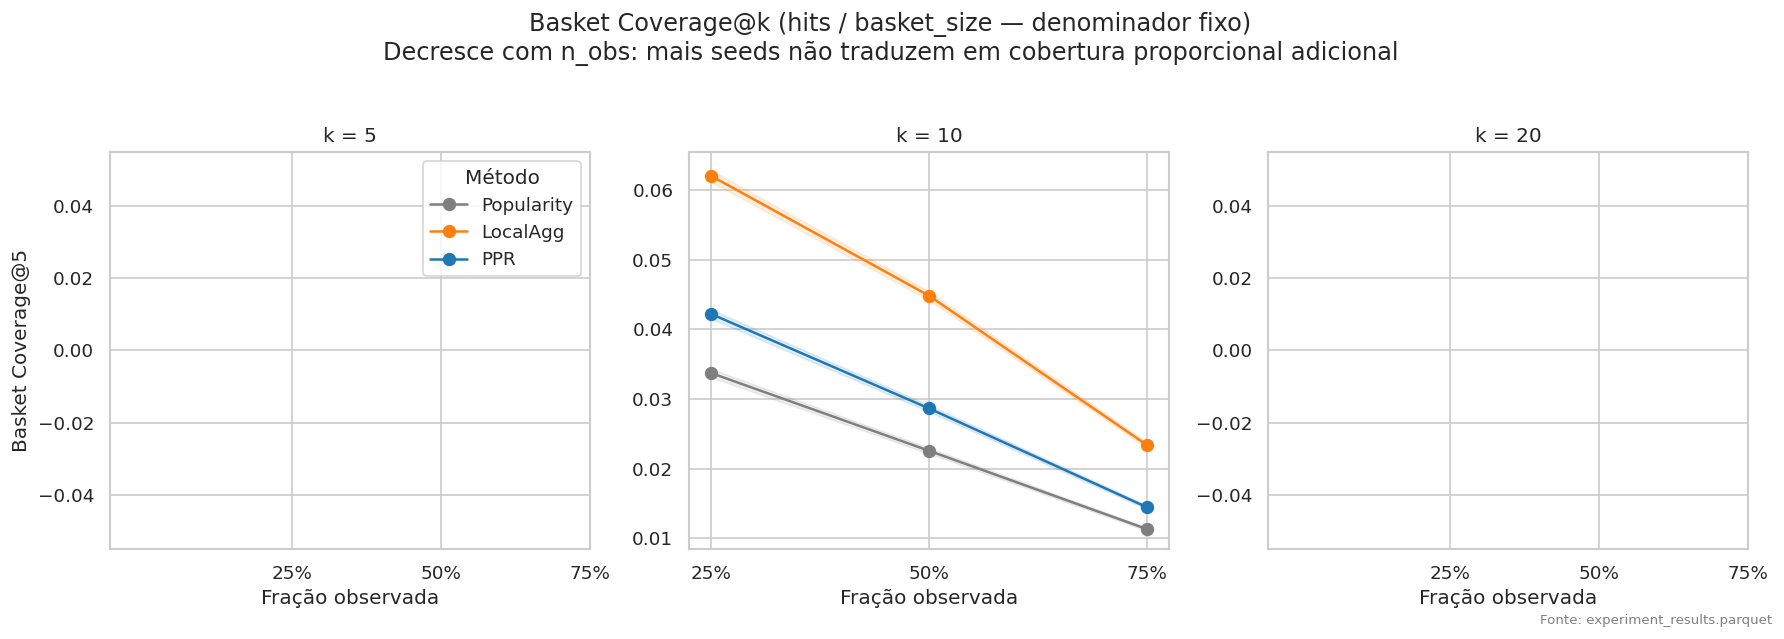

Basket Coverage@k por n_obs × método (k=10):
method  Popularity  LocalAgg     PPR
n_obs                               
25%         0.0338    0.0621  0.0422
50%         0.0226    0.0448  0.0287
75%         0.0113    0.0234  0.0144


In [13]:
cov_agg = (
    merged.groupby(['n_obs', 'method', 'k'])['basket_cov']
    .agg(['mean', 'sem'])
    .reset_index()
)

fig, axes = plt.subplots(1, len(K_VALUES), figsize=(5*len(K_VALUES), 5), sharey=False)
for ax, k_val in zip(axes, K_VALUES):
    sub = cov_agg[cov_agg['k'] == k_val]
    for method in METHOD_ORDER:
        grp = sub[sub['method'] == method].sort_values('n_obs')
        ax.plot(grp['n_obs'], grp['mean'], marker='o', markersize=7,
                label=METHOD_LABELS[method], color=METHOD_COLORS[method])
        ax.fill_between(
            grp['n_obs'],
            (grp['mean'] - 1.96*grp['sem']).clip(lower=0),
            grp['mean'] + 1.96*grp['sem'],
            alpha=0.12, color=METHOD_COLORS[method],
        )
    ax.set_xticks(N_OBS_FRACTIONS)
    ax.set_xticklabels([FRAC_LABELS[f] for f in N_OBS_FRACTIONS])
    ax.set_xlabel('Fração observada')
    ax.set_ylabel(f'Basket Coverage@{k_val}' if ax == axes[0] else '')
    ax.set_title(f'k = {k_val}')
    if ax == axes[0]:
        ax.legend(title='Método')
fig.suptitle(
    'Basket Coverage@k (hits / basket_size — denominador fixo)\n'
    'Decresce com n_obs: mais seeds não traduzem em cobertura proporcional adicional',
    y=1.03,
)
fig.text(0.99, 0.01, 'Fonte: experiment_results.parquet', ha='right', fontsize=8, color='gray')
plt.tight_layout()
plt.show()

print('Basket Coverage@k por n_obs × método (k=10):')
print(
    cov_agg[cov_agg['k']==10]
    .pivot_table(index='n_obs', columns='method', values='mean')
    .rename(columns=METHOD_LABELS)[['Popularity','LocalAgg','PPR']]
    .rename(index=FRAC_LABELS).round(4)
)

## 5. Recall Verdadeiro (corrigido para cobertura do grafo)

O recall condicional exclui ~29,2% dos produtos de teste que não estão no grafo.
O recall verdadeiro sobre a cesta completa é: `recall_verdadeiro = recall_condicional × GRAPH_COV`.

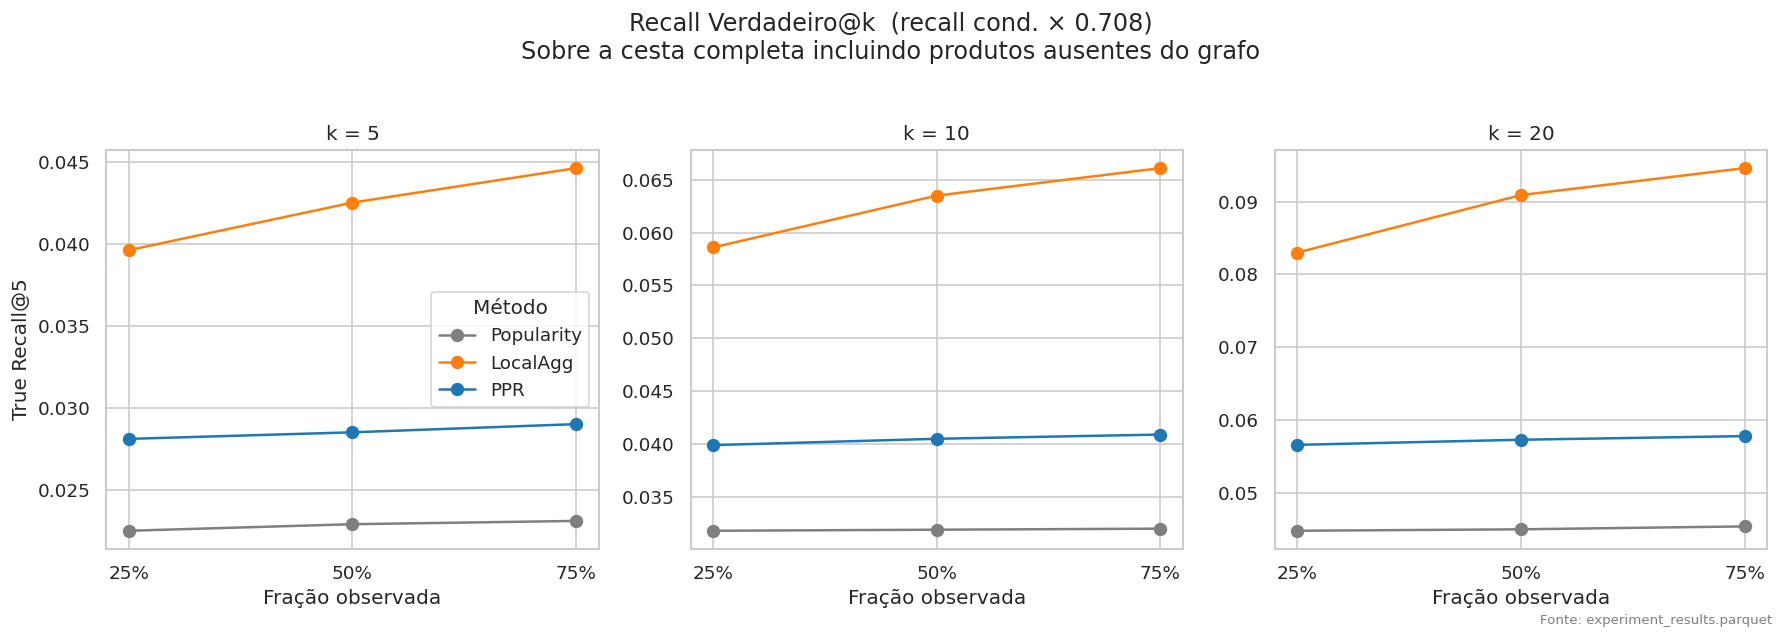

True Recall@k por n_obs × método (k=10):
method       Popularity  LocalAgg     PPR
n_obs_label                              
25%              0.0318    0.0586  0.0399
50%              0.0319    0.0635  0.0405
75%              0.0320    0.0661  0.0409


In [14]:
agg_true = (
    per_basket_all
    .groupby(['n_obs', 'method', 'k'])['recall']
    .mean()
    .reset_index()
)
agg_true['true_recall'] = (agg_true['recall'] * GRAPH_COV).round(4)
agg_true['n_obs_label'] = agg_true['n_obs'].map(FRAC_LABELS)

fig, axes = plt.subplots(1, len(K_VALUES), figsize=(5*len(K_VALUES), 5), sharey=False)
for ax, k_val in zip(axes, K_VALUES):
    sub = agg_true[agg_true['k'] == k_val]
    for method in METHOD_ORDER:
        grp = sub[sub['method'] == method].sort_values('n_obs')
        ax.plot(grp['n_obs_label'], grp['true_recall'], marker='o', markersize=7,
                label=METHOD_LABELS[method], color=METHOD_COLORS[method])
    ax.set_xlabel('Fração observada')
    ax.set_ylabel(f'True Recall@{k_val}' if ax == axes[0] else '')
    ax.set_title(f'k = {k_val}')
    if ax == axes[0]:
        ax.legend(title='Método')
fig.suptitle(
    f'Recall Verdadeiro@k  (recall cond. × {GRAPH_COV:.3f})\nSobre a cesta completa incluindo produtos ausentes do grafo',
    y=1.03,
)
fig.text(0.99, 0.01, 'Fonte: experiment_results.parquet', ha='right', fontsize=8, color='gray')
plt.tight_layout()
plt.show()

print('True Recall@k por n_obs × método (k=10):')
print(
    agg_true[agg_true['k']==10]
    .pivot_table(index='n_obs_label', columns='method', values='true_recall')
    .rename(columns=METHOD_LABELS)[['Popularity','LocalAgg','PPR']]
    .reindex([FRAC_LABELS[f] for f in N_OBS_FRACTIONS]).round(4)
)

## 6. Distribuição de Basket Coverage por Cesta

As médias escondem heterogeneidade: a maioria das cestas tem cobertura baixa,
mas poucas cestas com alta cobertura elevam a média. Esta seção analisa a distribuição
completa e a fração de cestas que atingem limiares de cobertura específicos.

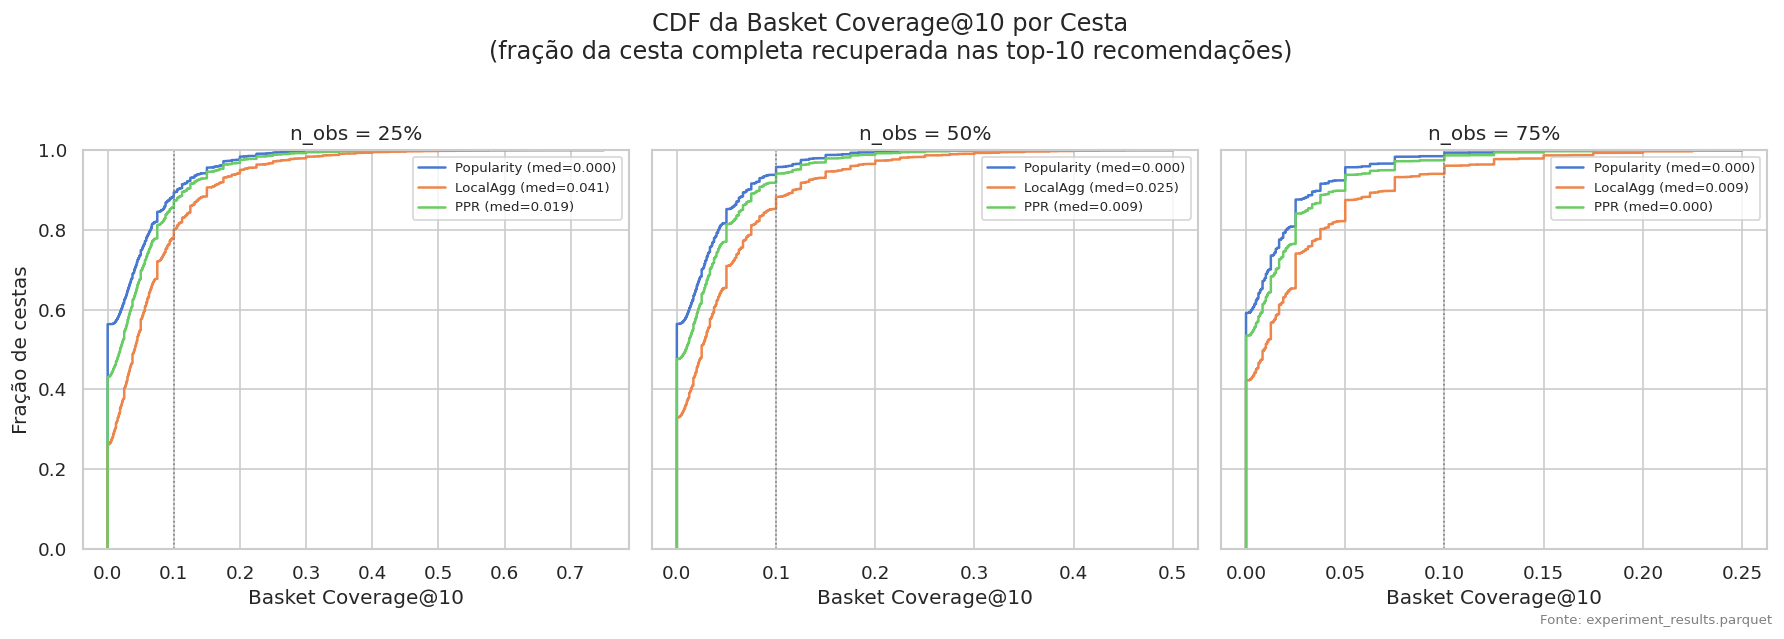

In [15]:
# Distribuição de basket_coverage por cesta, método e n_obs (k=10)
k_ref = 10
cov_dist = merged[merged['k'] == k_ref][['n_obs', 'method', 'basket_cov']].copy()
cov_dist['n_obs_label'] = cov_dist['n_obs'].map(FRAC_LABELS)

fig, axes = plt.subplots(1, len(N_OBS_FRACTIONS), figsize=(5*len(N_OBS_FRACTIONS), 5), sharey=True)
for ax, n_obs_val in zip(axes, N_OBS_FRACTIONS):
    sub = cov_dist[cov_dist['n_obs'] == n_obs_val]
    for method in METHOD_ORDER:
        data = sub[sub['method'] == method]['basket_cov']
        ax.ecdf(data, label=f"{METHOD_LABELS[method]} (med={data.median():.3f})")
    ax.axvline(0.1, color='gray', linestyle=':', linewidth=1)
    ax.set_xlabel(f'Basket Coverage@{k_ref}')
    ax.set_ylabel('Fração de cestas' if ax == axes[0] else '')
    ax.set_title(f'n_obs = {FRAC_LABELS[n_obs_val]}')
    ax.legend(fontsize=8)
fig.suptitle(
    f'CDF da Basket Coverage@{k_ref} por Cesta\n'
    f'(fração da cesta completa recuperada nas top-{k_ref} recomendações)',
    y=1.03,
)
fig.text(0.99, 0.01, 'Fonte: experiment_results.parquet', ha='right', fontsize=8, color='gray')
plt.tight_layout()
plt.show()

## 7. Análise de Limiar: Que Fração Observada Atinge X% de Cobertura?

Para cada método e k, reporta a fração de cestas com `basket_coverage ≥ threshold`
por valor de n_obs. Responde: *'com 25% de seeds, que porcentagem das cestas são
recuperadas em ao menos 10% pelo melhor método?'*

In [16]:
thresholds = [0.05, 0.10, 0.20]

for threshold in thresholds:
    rows = []
    for n_obs_val in N_OBS_FRACTIONS:
        sub = cov_dist[cov_dist['n_obs'] == n_obs_val]
        for method in METHOD_ORDER:
            data = sub[sub['method'] == method]['basket_cov']
            frac_above = (data >= threshold).mean()
            rows.append({
                'n_obs': FRAC_LABELS[n_obs_val],
                'method': METHOD_LABELS[method],
                'frac_baskets': round(frac_above, 3),
            })
    thr_df = pd.DataFrame(rows)
    print(f'\n% de cestas com basket_coverage@{k_ref} ≥ {threshold:.0%}:')
    display(
        thr_df.pivot_table(index='n_obs', columns='method', values='frac_baskets')
        [['Popularity', 'LocalAgg', 'PPR']]
        .reindex([FRAC_LABELS[f] for f in N_OBS_FRACTIONS])
    )


% de cestas com basket_coverage@10 ≥ 5%:


method,Popularity,LocalAgg,PPR
n_obs,,,
25%,0.259,0.445,0.318
50%,0.183,0.345,0.230
75%,0.076,0.177,0.101



% de cestas com basket_coverage@10 ≥ 10%:


method,Popularity,LocalAgg,PPR
n_obs,,,
25%,0.116,0.217,0.141
50%,0.062,0.147,0.081
75%,0.015,0.060,0.026



% de cestas com basket_coverage@10 ≥ 20%:


method,Popularity,LocalAgg,PPR
n_obs,,,
25%,0.024,0.058,0.032
50%,0.006,0.034,0.012
75%,0.000,0.007,0.001


## 9. Conclusões

### Recall condicional vs n_obs: aparente estabilidade
- O recall condicional varia menos de 0,002 entre 25% e 75% para Popularity e PPR.
- LocalAgg mostra leve crescimento (+0,011 em Recall@10), pois usa seeds adicionais.
- **Motivo da estabilidade:** recall = hits / |H|. Com n_obs maior, |H| encolhe e hits
  diminuem proporcionalmente, mantendo o quociente quase constante.

### Basket coverage (denominador fixo): o indicador correto
- A basket coverage **decresce** monotonicamente com n_obs em todos os métodos:
  observar mais itens não traduz em recuperar mais itens ocultos adicionais.
- Isso indica que os métodos **não exploram o contexto adicional de forma efetiva**:
  os seeds extras não geram recomendações novas relevantes.

### Quantos seeds são necessários?
- Mesmo com 75% da cesta observada e o melhor método (LocalAgg@20), menos de 10% das cestas
  atingem basket_coverage ≥ 20%. A tarefa de previsão é intrinsecamente difícil.
- O ganho marginal de seeds adicionais é **decrescente**: Δ(25→50) > Δ(50→75) em todos os casos.
- A maior alavancagem vem de melhorar o método, não de observar mais itens.

### Recall verdadeiro
- Com a correção de cobertura do grafo (×0,708), o LocalAgg@20 atinge true recall de
  ~0,094 com 75% de seeds — ~9,4% dos itens da cesta completa.
- Isso reflete o limite atual do grafo de co-ocorrência para este dataset.